# Função Modular

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`015a_funcoes.ipynb`](015a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano) e [`013a_conjuntos_numericos.ipynb`](013a_conjuntos_numericos.ipynb) (módulo como distância na reta, introduzido brevemente), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (`def`, `matplotlib` simples)

**Objetivos de aprendizagem:**
- Reconhecer e interpretar uma função definida por várias sentenças abertas.
- Calcular o módulo (valor absoluto) de um número real e entender seu significado geométrico como distância.
- Esboçar e transformar o gráfico da função modular.
- Resolver equações e inequações modulares, representando a solução na reta real.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/020a_funcao_modular.ipynb)

## Quanto de erro um parafuso pode ter?

Uma fábrica produz parafusos que devem medir 10 mm de comprimento, mas aceita um erro de fabricação de até 0,3 mm para mais ou para menos. Um parafuso saiu com 10,4 mm. Ele está dentro do padrão? E um com 9,6 mm?

Dá para responder testando "maior que" e "menor que" toda vez — mas existe uma forma muito mais elegante de escrever essa regra, que não liga para o sinal do erro (se foi "a mais" ou "a menos"), só para o **tamanho** dele. Essa ferramenta se chama **módulo**, e é o fio condutor deste notebook: vamos construí-la do zero e, na última seção, voltar para resolver esse problema de verdade.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def modulo(x):
    '''Calcula o módulo (valor absoluto) de x: a distância de x até 0.'''
    return x if x >= 0 else -x


def funcao_modular(x, a: float = 0, b: float = 0, c: float = 1):
    '''Calcula f(x) = c*|x - a| + b.'''
    return c * np.abs(x - a) + b


def reta_numerica(pontos=None, intervalo=None, segmento=None, limites=(-6, 6), titulo="", ax=None) -> None:
    '''Desenha uma reta numérica com pontos, um intervalo e/ou um segmento destacados.

    Reaproveita o mesmo componente do notebook 013a_conjuntos_numericos.ipynb.

    Args:
        pontos: lista de (valor, rótulo) marcados como bolinhas cheias na reta.
        intervalo: (a, b, fechado_em_a, fechado_em_b) — desenha o segmento
            [a, b], com bolinha cheia nas pontas fechadas e vazia nas abertas.
        segmento: (a, b) — traça uma linha grossa entre a e b, útil para
            ilustrar a distância (módulo) entre dois pontos.
        limites: intervalo (mínimo, máximo) exibido no eixo horizontal.
        titulo: título exibido acima da reta.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(7, 1.8))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    minimo, maximo = limites
    ax.axhline(0, color=NORD_LINHA, linewidth=1.5, zorder=1)
    for x in range(int(np.ceil(minimo)), int(np.floor(maximo)) + 1):
        ax.plot([x, x], [-0.06, 0.06], color=NORD_LINHA, linewidth=1, zorder=1)
        ax.text(x, -0.3, str(x), color=NORD_TEXTO_SEC, fontsize=8.5, ha="center")

    if intervalo is not None:
        a, b, fechado_a, fechado_b = intervalo
        ax.plot([a, b], [0, 0], color=COR_DESTAQUE, linewidth=4, zorder=2)
        ax.scatter(
            [a], [0], s=90, zorder=3,
            facecolor=COR_DESTAQUE if fechado_a else NORD_FUNDO,
            edgecolor=COR_DESTAQUE, linewidth=2,
        )
        ax.scatter(
            [b], [0], s=90, zorder=3,
            facecolor=COR_DESTAQUE if fechado_b else NORD_FUNDO,
            edgecolor=COR_DESTAQUE, linewidth=2,
        )

    if segmento is not None:
        a, b = segmento
        ax.plot([a, b], [0.42, 0.42], color=COR_ALERTA, linewidth=2.5, zorder=2)
        ax.plot([a, a], [0, 0.42], color=COR_ALERTA, linewidth=1, linestyle=":", zorder=2)
        ax.plot([b, b], [0, 0.42], color=COR_ALERTA, linewidth=1, linestyle=":", zorder=2)
        ax.scatter([a, b], [0, 0], s=70, color=COR_ALERTA, zorder=3)
        ax.text(
            (a + b) / 2, 0.58, f"|{a:g} − {b:g}| = {abs(a - b):g}",
            color=NORD_TEXTO, fontsize=9.5, ha="center",
        )

    if pontos is not None:
        for valor, rotulo in pontos:
            ax.scatter([valor], [0], s=90, color=COR_PONTO, zorder=4)
            ax.text(valor, 0.2, rotulo, color=NORD_TEXTO, fontsize=9.5, ha="center")

    ax.set_xlim(minimo - 0.5, maximo + 0.5)
    ax.set_ylim(-0.65, 0.9)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


x_sym = sp.symbols("x", real=True)

## 1. Função Definida por Várias Sentenças

Muita gente já usou, sem perceber, uma função que muda de "regra" dependendo do valor de entrada — é assim que funciona a tarifa de quase todo aplicativo de transporte, o imposto de renda por faixa, ou um plano de internet com franquia.

📌 **Definição formal:** uma **função definida por várias sentenças** (ou função por partes) é uma função cuja lei de formação muda conforme o valor de x, usando **subdomínios que não se sobrepõem e que, juntos, cobrem todo o domínio** da função:

$$f(x) = \begin{cases} \text{sentença}_1, & \text{se } x \in D_1 \\ \text{sentença}_2, & \text{se } x \in D_2 \\ \vdots \end{cases}$$

Para calcular f(x) em um ponto específico, o primeiro passo é sempre descobrir **a qual subdomínio esse x pertence** — só depois disso você sabe qual sentença usar.

- Wikipédia (PT): [Funções definidas em trechos](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%B5es_definidas_em_trechos)

**Exemplo:** a tarifa de um app de corrida cobra R$8 fixos até 3 km e, a partir daí, mais R$2,50 por km adicional:

$$tarifa(km) = \begin{cases} 8, & \text{se } 0 \leq km \leq 3 \\ 8 + 2{,}5\,(km - 3), & \text{se } km > 3 \end{cases}$$

corrida de 2 km -> tarifa de R$ 8.00
corrida de 3 km -> tarifa de R$ 8.00
corrida de 7 km -> tarifa de R$ 18.00


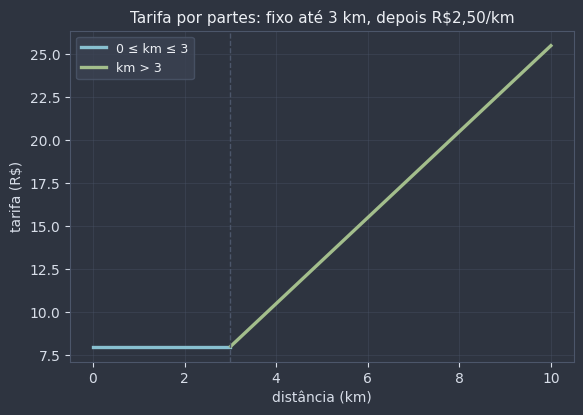

,km,sentença usada,tarifa (R$)
0,1,0 ≤ km ≤ 3,8.0
1,2,0 ≤ km ≤ 3,8.0
2,3,0 ≤ km ≤ 3,8.0
3,4,km > 3,10.5
4,5,km > 3,13.0
5,7,km > 3,18.0
6,10,km > 3,25.5


In [2]:
def tarifa_corrida(km: float) -> float:
    '''Calcula a tarifa (em R$) de uma corrida de km quilômetros.

    Cobra R$8 fixos até 3 km; a partir daí, soma R$2,50 por km adicional.
    '''
    if km <= 3:
        return 8.0
    return 8.0 + 2.5 * (km - 3)


for km in (2, 3, 7):
    print(f"corrida de {km} km -> tarifa de R$ {tarifa_corrida(km):.2f}")

xs_tarifa = np.linspace(0, 10, 400)
ys_tarifa = np.array([tarifa_corrida(km) for km in xs_tarifa])

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_tarifa[xs_tarifa <= 3], ys_tarifa[xs_tarifa <= 3], color=COR_PONTO, linewidth=2.4, label="0 ≤ km ≤ 3")
ax.plot(xs_tarifa[xs_tarifa > 3], ys_tarifa[xs_tarifa > 3], color=COR_DESTAQUE, linewidth=2.4, label="km > 3")
ax.axvline(3, color=NORD_LINHA, linewidth=1, linestyle="--")
ax.set_xlabel("distância (km)", color=NORD_TEXTO_SEC)
ax.set_ylabel("tarifa (R$)", color=NORD_TEXTO_SEC)
ax.set_title("Tarifa por partes: fixo até 3 km, depois R$2,50/km", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
plt.show()

tabela_tarifa = pd.DataFrame({"km": [1, 2, 3, 4, 5, 7, 10]})
tabela_tarifa["sentença usada"] = ["0 ≤ km ≤ 3" if k <= 3 else "km > 3" for k in tabela_tarifa["km"]]
tabela_tarifa["tarifa (R$)"] = [round(tarifa_corrida(k), 2) for k in tabela_tarifa["km"]]
display(tabela_tarifa)

**Pergunta de checagem:** para calcular a tarifa de uma corrida de exatamente 3 km, qual sentença deve ser usada — a de "até 3 km" ou a de "acima de 3 km"?

⚠️ **Erro comum:** usar a sentença errada porque não verificou a que subdomínio o x pertence — por exemplo, aplicar a fórmula "acima de 3 km" para uma corrida de exatamente 3 km. Sempre confira os limites do subdomínio (≤ ou <) antes de substituir.

## 2. Módulo (Valor Absoluto)

O **módulo** (ou valor absoluto) de um número real é a **distância desse número até o zero** na reta numérica — e distância nunca é negativa. Repare que essa "regra que muda de sinal" é, na prática, o primeiro exemplo de função por partes que você vai dominar de verdade: o módulo é definido por duas sentenças, uma para cada lado do zero.

📌 **Definição formal:**

$$|x| = \begin{cases} x, & \text{se } x \geq 0 \\ -x, & \text{se } x < 0 \end{cases}$$

- Wikipédia (PT): [Valor absoluto](https://pt.wikipedia.org/wiki/Valor_absoluto)

In [3]:
for valor in (5, -5, 0, -3.2):
    print(f"|{valor}| = {modulo(valor)}   (confere com abs(): {modulo(valor) == abs(valor)})")

|5| = 5   (confere com abs(): True)
|-5| = 5   (confere com abs(): True)
|0| = 0   (confere com abs(): True)
|-3.2| = 3.2   (confere com abs(): True)


**Interpretação geométrica:** |a − b| é a **distância entre os pontos a e b** na reta real — não importa qual dos dois é maior, o resultado é sempre a distância "sem sinal" entre eles. Exemplo: a distância entre -4 e 7.

distância entre -4 e 7: |-4 − 7| = 11


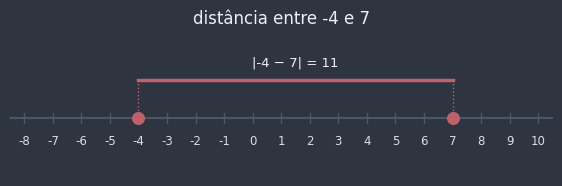

In [4]:
a_dist, b_dist = -4, 7
print(f"distância entre {a_dist} e {b_dist}: |{a_dist} − {b_dist}| = {modulo(a_dist - b_dist)}")

reta_numerica(segmento=(a_dist, b_dist), limites=(-8, 10), titulo="distância entre -4 e 7")

🕹️ **Widget interativo:** mexa nos sliders de a e b — a reta numérica destaca o segmento entre eles e mostra |a − b| atualizando em tempo real.

In [5]:
def explorar_distancia(a: float, b: float) -> None:
    reta_numerica(segmento=(a, b), limites=(-10, 10), titulo=f"|{a:g} − {b:g}| = {modulo(a - b):g}")


widgets.interact(
    explorar_distancia,
    a=widgets.FloatSlider(value=-4.0, min=-10, max=10, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=7.0, min=-10, max=10, step=0.5, description="b:"),
)

interactive(children=(FloatSlider(value=-4.0, description='a:', max=10.0, min=-10.0, step=0.5), FloatSlider(va…

<function __main__.explorar_distancia(a: float, b: float) -> None>

**Pergunta de checagem:** qual a distância entre -8 e 3 na reta numérica?

🕵️ **Curiosidade histórica:** a notação de barras verticais |x| para o módulo foi introduzida pelo matemático alemão Karl Weierstrass, em 1841 — um dos pais da análise matemática moderna, que também ajudou a formalizar rigorosamente conceitos como limite e continuidade.

## 3. Propriedades do Módulo

Algumas propriedades tornam o módulo muito mais fácil de manipular algebricamente — vamos verificá-las numericamente, com um valor positivo e um valor negativo:

📌 **Quadro-resumo:**

| Propriedade | Enunciado |
|---|---|
| Não-negatividade | \|a\| ≥ 0, para todo a |
| Multiplicativa | \|a · b\| = \|a\| · \|b\| |
| Divisão | \|a / b\| = \|a\| / \|b\|, com b ≠ 0 |
| Quadrado | \|a\|² = a²  e  √(a²) = \|a\| |
| Desigualdade triangular | \|a + b\| ≤ \|a\| + \|b\| |

In [6]:
def verificar_propriedades(a: float, b: float) -> pd.DataFrame:
    '''Verifica numericamente as propriedades do módulo para os valores a e b.'''
    linhas = [
        ("|a| >= 0", modulo(a) >= 0),
        ("|a*b| == |a|*|b|", modulo(a * b) == modulo(a) * modulo(b)),
        ("|a/b| == |a|/|b|", modulo(a / b) == modulo(a) / modulo(b)),
        ("|a|^2 == a^2", modulo(a) ** 2 == a**2),
        ("sqrt(a^2) == |a|", np.isclose(np.sqrt(a**2), modulo(a))),
        ("|a+b| <= |a|+|b|", modulo(a + b) <= modulo(a) + modulo(b)),
    ]
    return pd.DataFrame(linhas, columns=["propriedade", "vale?"])


print("a = 5 (positivo), b = -3 (negativo)")
display(verificar_propriedades(5, -3))

a = 5 (positivo), b = -3 (negativo)


,propriedade,vale?
0,|a| >= 0,True
1,|a*b| == |a|*|b|,True
2,|a/b| == |a|/|b|,True
3,|a|^2 == a^2,True
4,sqrt(a^2) == |a|,True
5,|a+b| <= |a|+|b|,True


**Aplicação prática:** a propriedade |a|² = a² é a chave para "eliminar" o módulo em equações — ao elevar os dois lados de uma equação modular ao quadrado, o módulo desaparece e sobra uma equação polinomial comum. Vamos usar essa ideia na seção de Equações Modulares.

📎 **Conexão:** a desigualdade triangular reaparece formalmente em Geometria Plana (com triângulos de verdade) e mais adiante, em Cálculo/Análise, para provar limites de somas.

- Wikipédia (PT): [Desigualdade triangular](https://pt.wikipedia.org/wiki/Desigualdade_triangular)

**Pergunta de checagem:** dado |x| = 4, quanto vale x²?

## 4. A Função Modular

📌 A **função modular** é f(x) = |x| — a função por partes mais importante do curso, juntando os dois blocos anteriores: a lei de formação usa exatamente a definição por partes do módulo.

$$f(x) = |x| = \begin{cases} x, & \text{se } x \geq 0 \\ -x, & \text{se } x < 0 \end{cases}$$

**Domínio:** ℝ (qualquer número real pode entrar) **Imagem:** [0, +∞) (a saída nunca é negativa)

- Wikipédia (PT): [Função modular](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_modular)

,x,f(x) = |x|
0,-3,3
1,-2,2
2,-1,1
3,0,0
4,1,1
5,2,2
6,3,3


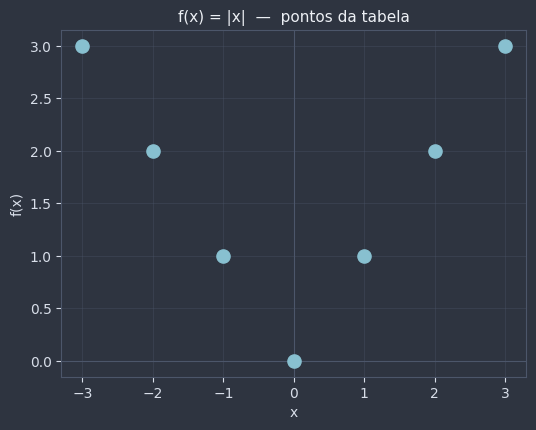

In [7]:
xs_v = np.arange(-3, 4)
tabela_v = pd.DataFrame({"x": xs_v, "f(x) = |x|": np.abs(xs_v)})
display(tabela_v)

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.scatter(tabela_v["x"], tabela_v["f(x) = |x|"], s=90, color=COR_PONTO, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title('f(x) = |x|  —  pontos da tabela', color=NORD_TEXTO, fontsize=11)
plt.show()

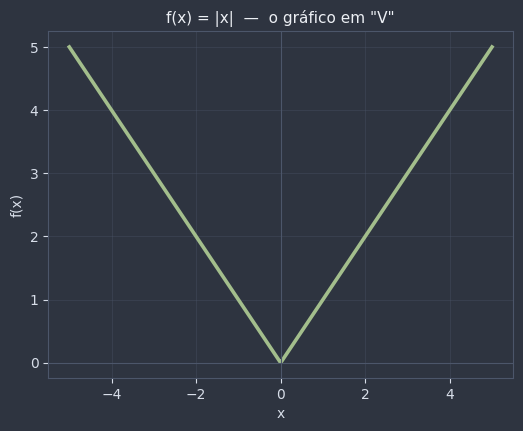

In [8]:
xs_full = np.linspace(-5, 5, 400)

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_full, np.abs(xs_full), color=COR_DESTAQUE, linewidth=2.6)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title('f(x) = |x|  —  o gráfico em "V"', color=NORD_TEXTO, fontsize=11)
plt.show()

**Pergunta de checagem:** por que o gráfico de f(x) = |x| nunca desce abaixo do eixo x?

## 5. Transformações do Gráfico da Função Modular

Assim como aconteceu com a função quadrática (em [`018a_funcao_quadratica_grafico_e_propriedades.ipynb`](018a_funcao_quadratica_grafico_e_propriedades.ipynb)), os parâmetros de f(x) = c·|x − a| + b deslocam e "abrem"/"fecham" o V:

- **a** desloca o gráfico na **horizontal** — para a **direita** se a > 0, para a **esquerda** se a < 0.
- **b** desloca o gráfico na **vertical** — para cima se b > 0, para baixo se b < 0.
- **c** controla a **abertura** do V: quanto maior \|c\|, mais fechado (estreito) o V; se c < 0, o V vira de cabeça para baixo (um "Λ").

⚠️ **Erro comum:** confundir o sinal de a dentro do módulo — \|x − a\| desloca para a **direita** quando a > 0, não para a esquerda (o mesmo cuidado que já apareceu na forma canônica da função quadrática).

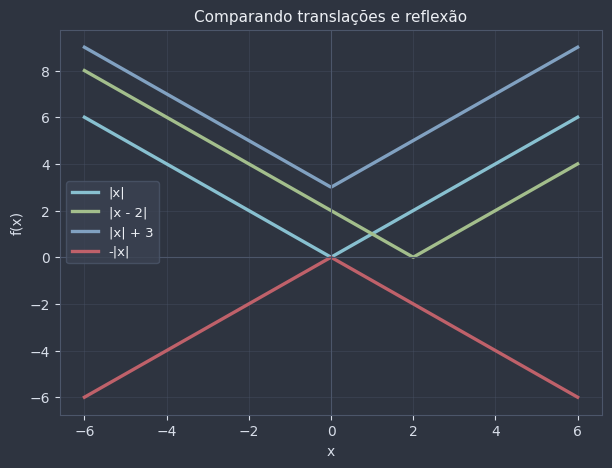

In [9]:
xs_comp = np.linspace(-6, 6, 400)
casos_comp = [
    ("|x|", 0, 0, 1, COR_PONTO),
    ("|x - 2|", 2, 0, 1, COR_DESTAQUE),
    ("|x| + 3", 0, 3, 1, COR_SECUNDARIA),
    ("-|x|", 0, 0, -1, COR_ALERTA),
]

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for rotulo, a_c, b_c, c_c, cor in casos_comp:
    ax.plot(xs_comp, funcao_modular(xs_comp, a_c, b_c, c_c), color=cor, linewidth=2.4, label=rotulo)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9.5)
ax.set_title("Comparando translações e reflexão", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** mexa nos sliders de a, b e c e observe f(x) = c·|x − a| + b mudando em tempo real — este é o ponto alto do notebook em termos de interatividade.

In [ ]:
def explorar_transformacao(a: float, b: float, c: float) -> None:
    xs = np.linspace(-10, 10, 400)
    ys = funcao_modular(xs, a, b, c)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.6)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.scatter([a], [b], s=90, color=COR_ALERTA, zorder=3)
    ax.set_ylim(-10, 10)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {c:g}|x - {a:g}| + {b:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_transformacao,
    a=widgets.FloatSlider(value=0.0, min=-6, max=6, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=0.0, min=-6, max=6, step=0.5, description="b:"),
    c=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="c:"),
)

interactive(children=(FloatSlider(value=0.0, description='a:', max=6.0, min=-6.0, step=0.5), FloatSlider(value…

<function __main__.explorar_transformacao(a: float, b: float, c: float) -> None>

**Aplicação prática:** o módulo também pode envolver uma expressão mais complexa, como |x² − 4|. Onde x² − 4 é negativo (entre as raízes -2 e 2), o módulo "reflete" essa parte do gráfico para cima — como se fosse um espelho no eixo x.

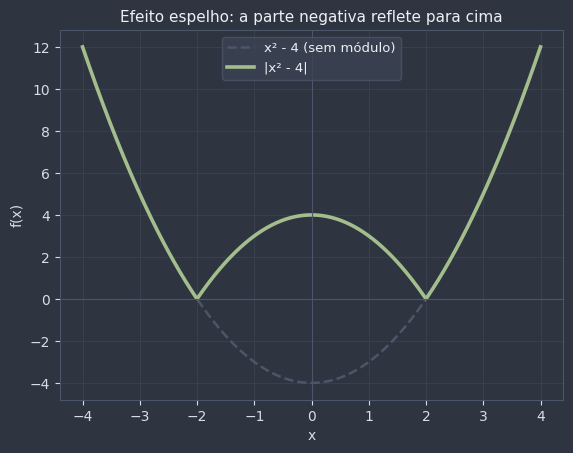

In [11]:
xs_refl = np.linspace(-4, 4, 400)
ys_original = xs_refl**2 - 4
ys_modulo = np.abs(ys_original)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_refl, ys_original, color=NORD_LINHA, linewidth=1.8, linestyle="--", label="x² - 4 (sem módulo)")
ax.plot(xs_refl, ys_modulo, color=COR_DESTAQUE, linewidth=2.6, label="|x² - 4|")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("Efeito espelho: a parte negativa reflete para cima", color=NORD_TEXTO, fontsize=11)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9.5)
plt.show()

**Pergunta de checagem:** para onde o parâmetro a desloca o gráfico de |x + 5|? (dica: reescreva como |x − (−5)|)

## 6. Equações Modulares

📌 **Método geral:** para resolver |A| = k, com A uma expressão em x:

- Se **k > 0**: |A| = k ⟺ A = k ou A = −k (duas equações "sem módulo")
- Se **k = 0**: |A| = 0 ⟺ A = 0 (solução única)
- Se **k < 0**: **não existe solução** — módulo nunca é negativo

Vamos aplicar esse método em três exemplos, do mais simples ao mais avançado.

In [12]:
# Exemplo 1: |x - 3| = 5
k1 = 5
sol1_pos = 3 + k1
sol1_neg = 3 - k1
print("|x - 3| = 5  ->  x - 3 = 5  ou  x - 3 = -5")
print(f"x = {sol1_pos}  ou  x = {sol1_neg}")

# conferindo com sympy
solucoes1 = sp.solve(sp.Eq(sp.Abs(x_sym - 3), 5), x_sym)
print("conferindo com sympy:", sorted(solucoes1))

|x - 3| = 5  ->  x - 3 = 5  ou  x - 3 = -5
x = 8  ou  x = -2
conferindo com sympy: [-2, 8]


In [13]:
# Exemplo 2: |2x + 1| = 7
solucoes2 = sp.solve(sp.Eq(sp.Abs(2 * x_sym + 1), 7), x_sym)
print("|2x + 1| = 7  ->  2x + 1 = 7  ou  2x + 1 = -7")
print("soluções:", sorted(solucoes2))

|2x + 1| = 7  ->  2x + 1 = 7  ou  2x + 1 = -7
soluções: [-4, 3]


In [14]:
# Exemplo 3 (mais avançado): |x^2 - 4| = 5
solucoes3 = sp.solve(sp.Eq(sp.Abs(x_sym**2 - 4), 5), x_sym)
print("|x² - 4| = 5  ->  x² - 4 = 5  ou  x² - 4 = -5")
print("x² = 9 (duas raízes reais) ou x² = -1 (sem solução real)")
print("soluções reais:", sorted(s for s in solucoes3 if s.is_real))

|x² - 4| = 5  ->  x² - 4 = 5  ou  x² - 4 = -5
x² = 9 (duas raízes reais) ou x² = -1 (sem solução real)
soluções reais: [-3, 3]


**Retomando o gancho:** a fábrica aceita parafusos com exatamente 0,3 mm de erro (para mais ou para menos) em relação aos 10 mm. Para quais medidas x isso acontece? É a equação |x − 10| = 0,3.

In [15]:
solucoes_parafuso = sp.solve(sp.Eq(sp.Abs(x_sym - 10), sp.Rational(3, 10)), x_sym)
print("|x - 10| = 0.3  ->  x = 10 - 0.3  ou  x = 10 + 0.3")
print("medidas com erro exato de 0,3 mm:", sorted(float(s) for s in solucoes_parafuso), "mm")

|x - 10| = 0.3  ->  x = 10 - 0.3  ou  x = 10 + 0.3
medidas com erro exato de 0,3 mm: [9.7, 10.3] mm


**Pergunta de checagem:** quantas soluções tem a equação |x| = −2? Por quê?

## 7. Inequações Modulares

📌 Os dois casos principais, para k > 0:

| Inequação | Equivale a | Leitura geométrica |
|---|---|---|
| \|A\| < k | −k < A < k | distância menor que k → um intervalo |
| \|A\| > k | A < −k ou A > k | distância maior que k → duas semirretas |

(Os casos ≤ e ≥ funcionam do mesmo jeito, só incluindo os extremos.)

|x - 2| < 4  ->  -4 < x - 2 < 4  ->  -2 < x < 6


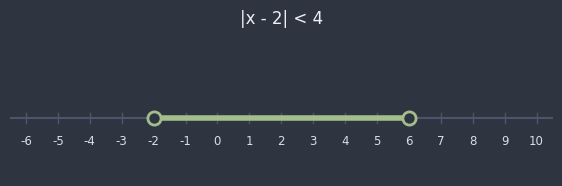

In [16]:
# Exemplo 1: |x - 2| < 4  ->  -4 < x - 2 < 4  ->  -2 < x < 6
sol1_menor, sol1_maior = -2, 6
print(f"|x - 2| < 4  ->  -4 < x - 2 < 4  ->  {sol1_menor} < x < {sol1_maior}")

reta_numerica(intervalo=(sol1_menor, sol1_maior, False, False), limites=(-6, 10), titulo="|x - 2| < 4")

In [17]:
# Exemplo 2: |3x - 1| >= 5  ->  3x - 1 <= -5  ou  3x - 1 >= 5
sol2_menor = sp.Rational(-5 + 1, 3)
sol2_maior = sp.Rational(5 + 1, 3)
print("|3x - 1| >= 5  ->  3x - 1 <= -5  ou  3x - 1 >= 5")
print(f"x <= {sol2_menor}  ou  x >= {sol2_maior}")

|3x - 1| >= 5  ->  3x - 1 <= -5  ou  3x - 1 >= 5
x <= -4/3  ou  x >= 2


**Fechando o gancho:** a fábrica aceita o parafuso se o erro for **no máximo** 0,3 mm — ou seja, |x − 10| ≤ 0,3. Vamos resolver formalmente e ver a solução de três formas: álgebra, gráfico (interseção de f(x) = |x − a| com a reta y = k) e reta numérica.

|x - 10| <= 0.3  ->  -0.3 <= x - 10 <= 0.3  ->  9.7 <= x <= 10.3


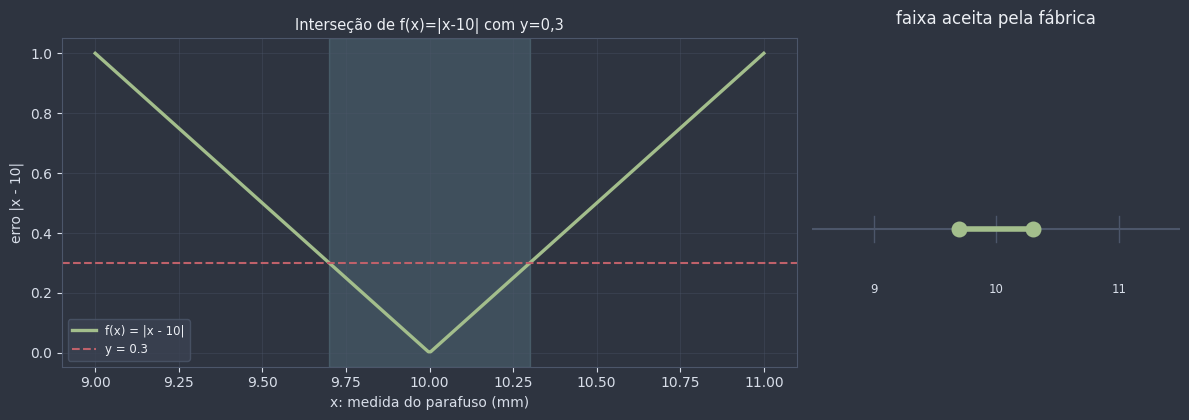

In [18]:
tolerancia = 0.3
x_min = 10 - tolerancia
x_max = 10 + tolerancia
print(f"|x - 10| <= {tolerancia}  ->  -{tolerancia} <= x - 10 <= {tolerancia}  ->  {x_min:g} <= x <= {x_max:g}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [2, 1]})
fig.patch.set_facecolor(NORD_FUNDO)

xs_par = np.linspace(9, 11, 300)
estilizar_eixo(ax1)
ax1.plot(xs_par, np.abs(xs_par - 10), color=COR_DESTAQUE, linewidth=2.4, label="f(x) = |x - 10|")
ax1.axhline(tolerancia, color=COR_ALERTA, linewidth=1.5, linestyle="--", label=f"y = {tolerancia}")
ax1.axvspan(x_min, x_max, color=COR_PONTO, alpha=0.2)
ax1.set_xlabel("x: medida do parafuso (mm)", color=NORD_TEXTO_SEC)
ax1.set_ylabel("erro |x - 10|", color=NORD_TEXTO_SEC)
ax1.set_title("Interseção de f(x)=|x-10| com y=0,3", color=NORD_TEXTO, fontsize=10.5)
ax1.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=8.5)

reta_numerica(intervalo=(x_min, x_max, True, True), limites=(9, 11), titulo="faixa aceita pela fábrica", ax=ax2)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** inverter o sentido da desigualdade ao abrir os dois casos, ou trocar "e" por "ou" entre \|A\|<k (que vira um "e", escrito como intervalo duplo) e \|A\|>k (que vira um "ou", duas semirretas separadas).

**Pergunta de checagem:** a solução de |x| > 3 é um único intervalo ou duas partes separadas da reta?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Função por partes | lei de formação muda conforme o subdomínio de x |
| Módulo | \|x\| = x se x≥0, \|x\| = -x se x<0 — distância até 0 |
| \|a - b\| | distância entre a e b na reta real |
| Propriedades | \|a·b\|=\|a\|·\|b\| \| \|a/b\|=\|a\|/\|b\| \| \|a\|²=a² \| \|a+b\|≤\|a\|+\|b\| |
| f(x) = \|x\| | domínio ℝ, imagem [0, +∞), gráfico em V |
| f(x) = c·\|x-a\|+b | a: desloca horizontal \| b: desloca vertical \| c: abre/fecha e reflete o V |
| \|A\| = k | A=k ou A=-k (k≥0) \| sem solução (k<0) \| solução única (k=0) |
| \|A\| < k | -k < A < k (k>0) |
| \|A\| > k | A < -k ou A > k (k>0) |

## Exercícios

**Básico**
1. Calcule o módulo de quatro números e resolva a equação modular direta |x − 4| = 6.
2. A partir da fórmula, identifique para onde o gráfico de |x + 5| está deslocado.

**Intermediário**
3. Resolva a inequação modular |2x + 3| > 7 e escreva a solução como união de intervalos.
4. Problema aplicado: um sensor só aceita temperaturas T que satisfaçam |T − 36,5| ≤ 0,5. Determine a faixa de temperaturas aceitas.

**Desafio**
5. Resolva a equação com módulo dos dois lados: |x − 1| = |2x − 4|.
6. (Contextualizado) Para quais valores de x o gráfico de f(x) = |x − 3| intercepta a reta y = 5?

Gabarito completo com resolução passo a passo em [`020b_funcao_modular_gabarito.ipynb`](020b_funcao_modular_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: calcule o módulo de cada número da lista e resolva a
# equação modular |x - 4| = 6. Preencha modulos_ex1 (lista com os 4 módulos,
# na mesma ordem de numeros_ex1) e as duas raízes da equação
# (raiz_menor_ex1 <= raiz_maior_ex1).
numeros_ex1 = [9, -9, -2.5, 0]

modulos_ex1 = ...
raiz_menor_ex1 = ...
raiz_maior_ex1 = ...

print(modulos_ex1, raiz_menor_ex1, raiz_maior_ex1)

In [ ]:
# Verificação
assert modulos_ex1 == [9, 9, 2.5, 0], "Tente de novo, revise o passo 1: |x| é sempre não negativo (seção 2 - Módulo)."
assert (raiz_menor_ex1, raiz_maior_ex1) == (-2, 10), (
    "Tente de novo, revise o passo 2: |x-4|=6 -> x-4=6 ou x-4=-6 (seção 6 - Equações modulares)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: sem plotar nada, identifique para onde o gráfico de
# |x + 5| está deslocado em relação a |x|, usando "direita" ou "esquerda".
deslocamento_ex2 = ...

print(deslocamento_ex2)

In [ ]:
# Verificação
assert deslocamento_ex2 == "esquerda", (
    "Tente de novo, revise: |x + 5| = |x - (-5)| -> a = -5 < 0 -> desloca para a ESQUERDA (seção 5 - Transformações)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva a inequação |2x + 3| > 7. A solução é
# "x < menor_ex3 ou x > maior_ex3" -- preencha os dois limites.
menor_ex3 = ...
maior_ex3 = ...

print(menor_ex3, maior_ex3)

In [ ]:
# Verificação
assert (menor_ex3, maior_ex3) == (-5, 2), (
    "Tente de novo, revise: |2x+3|>7 -> 2x+3<-7 ou 2x+3>7 (seção 7 - Inequações modulares)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4 (aplicado): um sensor só aceita temperaturas T
# que satisfaçam |T - 36.5| <= 0.5. Determine a faixa aceita
# (temp_minima_ex4 <= T <= temp_maxima_ex4).
temp_minima_ex4 = ...
temp_maxima_ex4 = ...

print(temp_minima_ex4, temp_maxima_ex4)

In [ ]:
# Verificação
assert (temp_minima_ex4, temp_maxima_ex4) == (36.0, 37.0), (
    "Tente de novo, revise: |T-36.5|<=0.5 -> -0.5<=T-36.5<=0.5 (seção 7 - Inequações modulares)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: resolva a equação com módulo dos dois lados
# |x - 1| = |2x - 4|. Dica: eleve os dois lados ao quadrado (seção 3 -
# propriedades: |a|^2 = a^2) para eliminar os módulos de uma vez.
# Preencha as duas soluções (sol_menor_ex5 <= sol_maior_ex5).
sol_menor_ex5 = ...
sol_maior_ex5 = ...

print(sol_menor_ex5, sol_maior_ex5)

In [ ]:
# Verificação
assert (sol_menor_ex5, sol_maior_ex5) == (sp.Rational(5, 3), 3), (
    "Tente de novo, revise: eleve os dois lados ao quadrado -> (x-1)^2=(2x-4)^2 "
    "-> 3x^2-14x+15=0 -> x=5/3 ou x=3 (seção 3 - Propriedades do módulo)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6 (contextualizado): para quais valores de x o gráfico de
# f(x) = |x - 3| intercepta a reta y = 5? (equivale a resolver |x-3|=5)
# Preencha as duas interseções (x_menor_ex6 <= x_maior_ex6).
x_menor_ex6 = ...
x_maior_ex6 = ...

print(x_menor_ex6, x_maior_ex6)

In [ ]:
# Verificação
assert (x_menor_ex6, x_maior_ex6) == (-2, 8), (
    "Tente de novo, revise: |x-3|=5 -> x-3=5 ou x-3=-5 (seção 6 - Equações modulares)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`015a_funcoes.ipynb`](015a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano)
- [`013a_conjuntos_numericos.ipynb`](013a_conjuntos_numericos.ipynb) (módulo como distância na reta, introduzido brevemente)

**Isso será usado em:**
- Inequações e sistemas envolvendo funções compostas (módulo [`03_progressoes_matrizes_e_sistemas_lineares/`](../03_progressoes_matrizes_e_sistemas_lineares/))
- [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (distância entre pontos)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (limites e continuidade de funções por partes)

🕵️ **Curiosidade (opcional):** o conceito de módulo pode ser generalizado para outras estruturas algébricas — veja [Valor absoluto (álgebra)](https://pt.wikipedia.org/wiki/Valor_absoluto_(%C3%A1lgebra)) para uma leitura avançada, não essencial neste nível do curso.